==== CE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800
Season amp A : 1.895122 cm   (peak-to-trough 3.790245 cm)

==== WC fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357
Season amp A : 1.300848 cm   (peak-to-trough 2.601696 cm)

==== WE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744
Season amp A : 4.024262 cm   (peak-to-trough 8.048523 cm)

Common mode (PC1) variance explained from residuals (Pc+season removed): 75.9%
Loadings [CE, WC, WE]: [-0.19679908 -0.31775724 -0.92752383] 



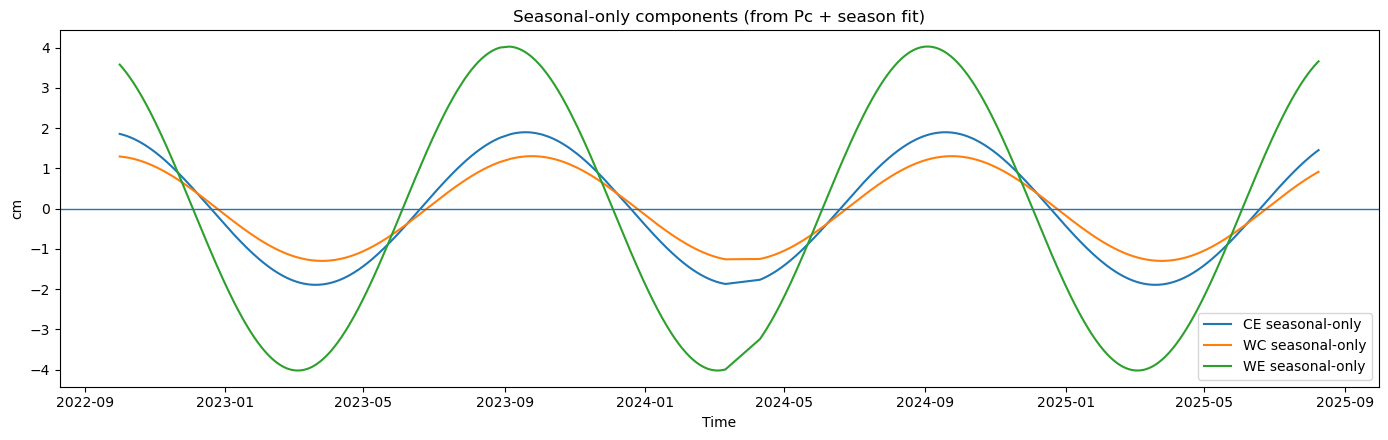

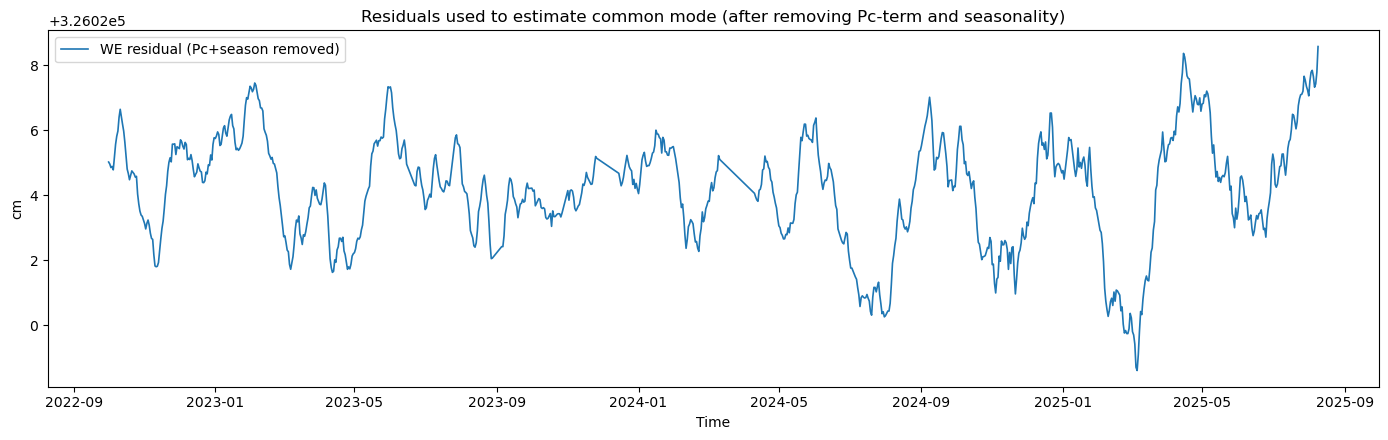

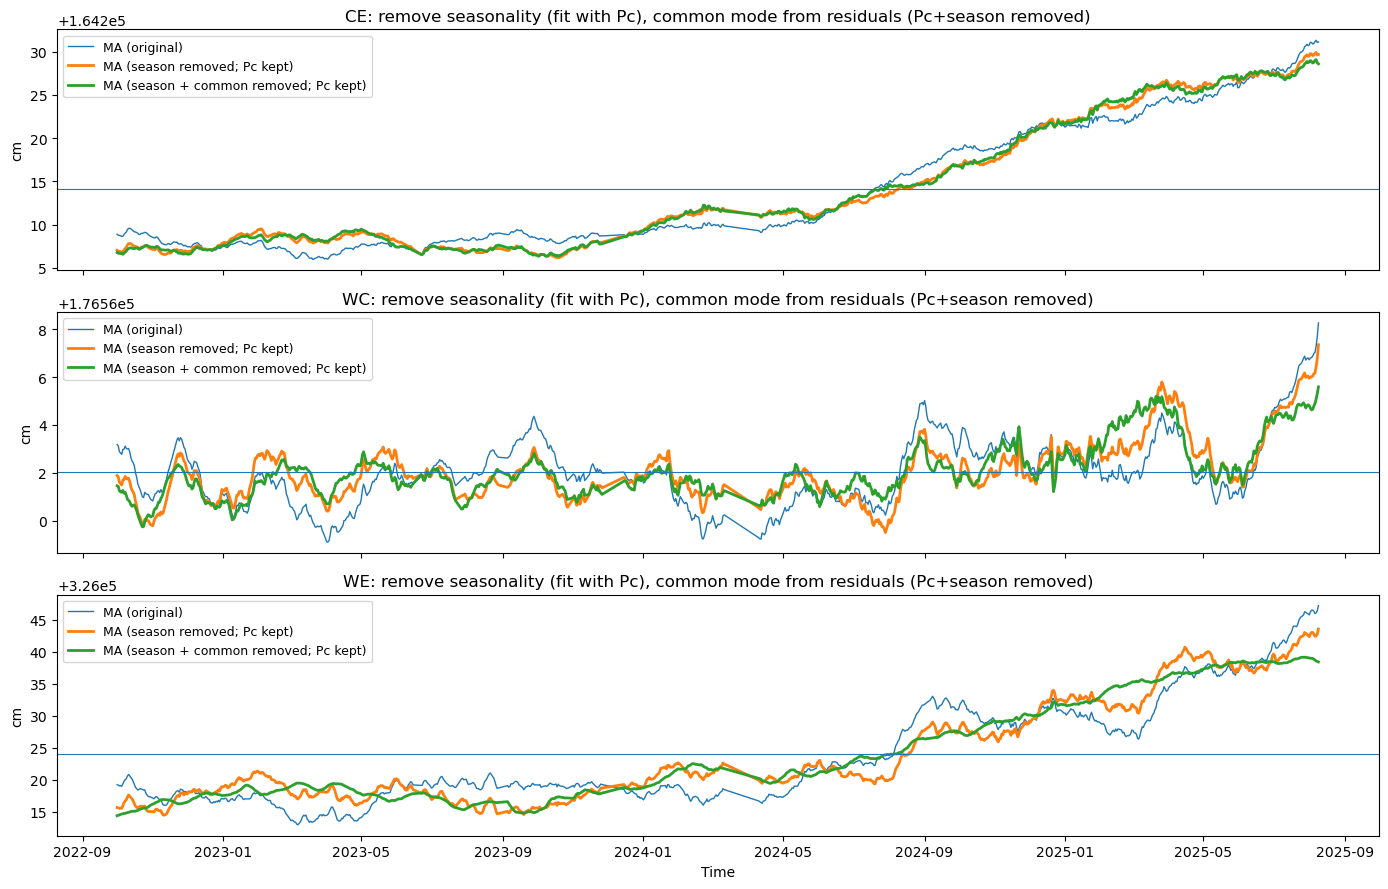

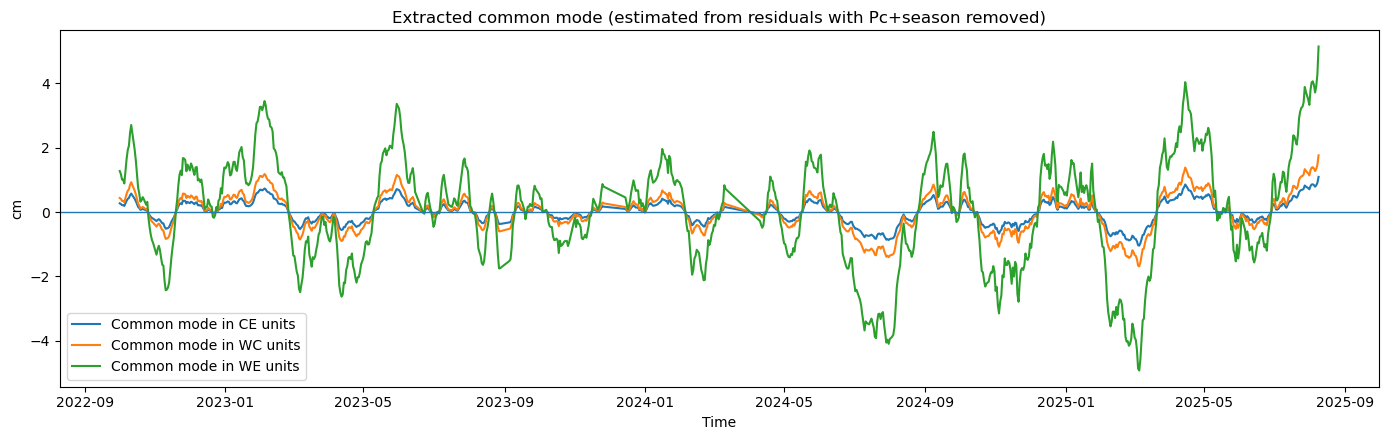

                             Pc_kPa       CE_MA_cm   CE_Pc_z  CE_pc_only  \
2022-10-01 00:00:00+00:00  1.347564  164208.878424  1.198450   -8.791673   
2022-10-02 00:00:00+00:00  1.345193  164208.764039  1.196292   -8.775839   
2022-10-03 00:00:00+00:00  1.341670  164208.739371  1.193085   -8.752316   
2022-10-04 00:00:00+00:00  1.336950  164208.689869  1.188788   -8.720794   
2022-10-05 00:00:00+00:00  1.331513  164208.640640  1.183840   -8.684494   

                           CE_season_only         CE_fit  \
2022-10-01 00:00:00+00:00        1.853800  164207.240615   
2022-10-02 00:00:00+00:00        1.846755  164207.249404   
2022-10-03 00:00:00+00:00        1.839164  164207.265336   
2022-10-04 00:00:00+00:00        1.831029  164207.288722   
2022-10-05 00:00:00+00:00        1.822351  164207.316345   

                           CE_resid_PcSeason_removed       WC_MA_cm   WC_Pc_z  \
2022-10-01 00:00:00+00:00              164215.816297  176563.181547  1.198450   
2022-10-02 00:00:00+

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOAL (your updated workflow)
#
# For each baseline (CE, WC, WE):
#   1) Fit baseline MA with: y = a + b*Pc_z + c*sin + d*cos
#   2) Seasonal signal = c*sin + d*cos
#   3) Residual_for_common = y - (b*Pc_z + seasonal)
#      (i.e., remove both Pc-dependent term AND seasonality)
#   4) Find common mode from these residuals (SVD/PCA on T x 3 matrix)
#   5) Final output series (what you asked):
#        From length remove seasonality + common mode (Pc kept)
#        y_final = y - seasonal - common_mode
# ============================================================

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

# -----------------------------
# Loaders
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit: y = a + b*Pc_z + c*sin + d*cos
# Return components and coeffs
# -----------------------------
def fit_pc_plus_season(y_series, pc_series, t0_common):
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    pc_only = b * Pc_z
    intercept = a * np.ones_like(y)

    amp = float(np.sqrt(c*c + d*d))
    fit = intercept + pc_only + season_only

    return {
        "a": a, "b": b, "c": c, "d": d, "amp": amp,
        "Pc_z": Pc_z,
        "pc_only": pc_only,
        "season_only": season_only,
        "fit": fit
    }

# -----------------------------
# Common mode from residuals (T x 3):
#   - center columns
#   - take PC1 reconstruction
# -----------------------------
def common_mode_from_residuals(R):
    # R: (T x 3)
    R_mean = R.mean(axis=0, keepdims=True)
    R0 = R - R_mean

    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    pc1 = U[:, 0] * S[0]
    loadings = Vt[0, :]

    R_common = np.outer(pc1, loadings)          # (T x 3) common-mode contribution
    var_expl = (S[0]**2) / np.sum(S**2)

    return R_common, loadings, var_expl

# ============================================================
# MAIN
# ============================================================

# 1) Load daily MA series + Pc
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")
pc = load_pc_daily(PC_FILE)

# 2) Align to common daily window
df = pd.concat([ce, wc, we, pc], axis=1).dropna()
t = df.index
t0_common = t[0]  # consistent phase origin for annual sin/cos

out = pd.DataFrame(index=t)
out["Pc_kPa"] = df["Pc_kPa"]

# 3) Fit each baseline, then build:
#    - season_only
#    - pc_only
#    - residual_for_common = y - (pc_only + season_only)
fits = {}
for name in ["CE", "WC", "WE"]:
    y = df[name]
    out[f"{name}_MA_cm"] = y

    f = fit_pc_plus_season(y, df["Pc_kPa"], t0_common)
    fits[name] = f

    out[f"{name}_Pc_z"] = f["Pc_z"]
    out[f"{name}_pc_only"] = f["pc_only"]
    out[f"{name}_season_only"] = f["season_only"]
    out[f"{name}_fit"] = f["fit"]

    # Key residual you asked for (Pc term + seasonality removed)
    out[f"{name}_resid_PcSeason_removed"] = y.to_numpy() - (f["pc_only"] + f["season_only"])

    print(f"==== {name} fit y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"a (intercept): {f['a']:.6f}")
    print(f"b (Pc_z)     : {f['b']:.6f}")
    print(f"c (sin)      : {f['c']:.6f}")
    print(f"d (cos)      : {f['d']:.6f}")
    print(f"Season amp A : {f['amp']:.6f} cm   (peak-to-trough {2*f['amp']:.6f} cm)\n")

# 4) Find common mode from the residuals (Pc+season removed)
R = np.column_stack([
    out["CE_resid_PcSeason_removed"].to_numpy(),
    out["WC_resid_PcSeason_removed"].to_numpy(),
    out["WE_resid_PcSeason_removed"].to_numpy()
])  # (T x 3)

R_common, loadings, var_expl = common_mode_from_residuals(R)
print(f"Common mode (PC1) variance explained from residuals (Pc+season removed): {100*var_expl:.1f}%")
print("Loadings [CE, WC, WE]:", loadings, "\n")

# Store common-mode contribution in each baseline's units (on residual space)
out["CE_common_from_resid"] = R_common[:, 0]
out["WC_common_from_resid"] = R_common[:, 1]
out["WE_common_from_resid"] = R_common[:, 2]

# 5) Final series you asked for:
#    From length remove seasonality + common mode (Pc kept)
for name in ["CE", "WC", "WE"]:
    out[f"{name}_season_removed"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"]  # Pc kept
    out[f"{name}_season_common_removed"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common_from_resid"]

# ============================================================
# PLOTS
# ============================================================

# Plot 1: seasonal-only terms (from Pc+season fit)
plt.figure(figsize=(14, 4.5))
for name in ["CE", "WC", "WE"]:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Seasonal-only components (from Pc + season fit)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: residuals used for common mode (Pc+season removed)
plt.figure(figsize=(14, 4.5))
for name in ["WE"]:
    plt.plot(out.index, out[f"{name}_resid_PcSeason_removed"], lw=1.2, label=f"{name} residual (Pc+season removed)")
#plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Residuals used to estimate common mode (after removing Pc-term and seasonality)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: baseline MA vs season-removed vs season+common removed (Pc kept in both of these)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_season_removed"], lw=2.0, label="MA (season removed; Pc kept)")
    ax.plot(out.index, out[f"{name}_season_common_removed"], lw=2.0, label="MA (season + common removed; Pc kept)")
    ax.axhline(out[f"{name}_MA_cm"].mean(), lw=0.8)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: remove seasonality (fit with Pc), common mode from residuals (Pc+season removed)")
    ax.legend(fontsize=9)
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot 4: extracted common mode contribution (in each baseline’s units)
plt.figure(figsize=(14, 4.5))
plt.plot(out.index, out["CE_common_from_resid"], lw=1.5, label="Common mode in CE units")
plt.plot(out.index, out["WC_common_from_resid"], lw=1.5, label="Common mode in WC units")
plt.plot(out.index, out["WE_common_from_resid"], lw=1.5, label="Common mode in WE units")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Extracted common mode (estimated from residuals with Pc+season removed)")
plt.legend()
plt.tight_layout()
plt.show()

print(out.head())

# OPTIONAL SAVE
# out.to_csv("season_common_removed_Pc_kept.csv")
# print("Saved: season_common_removed_Pc_kept.csv")


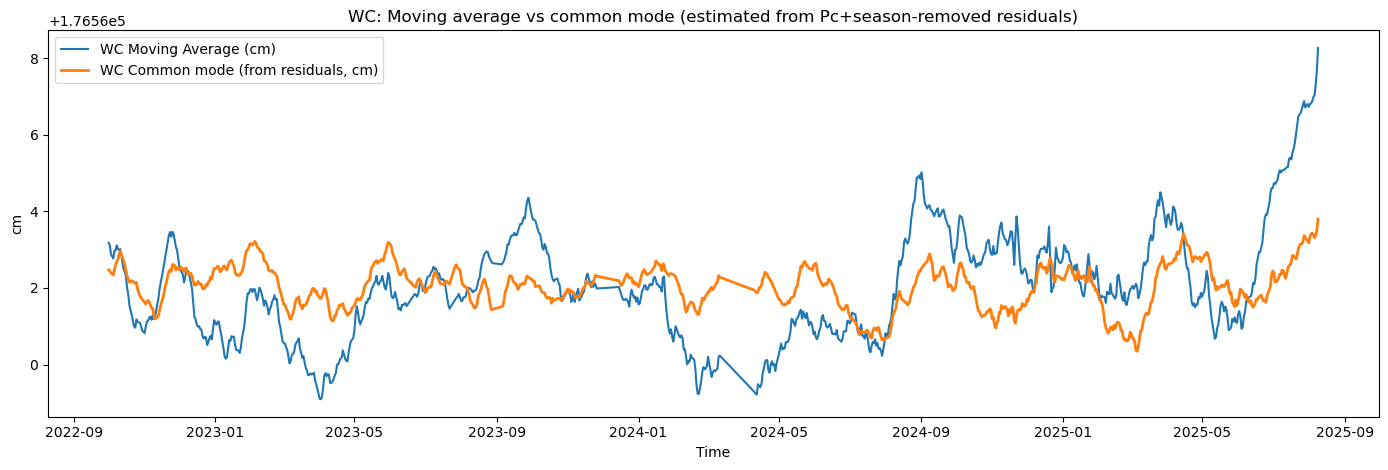

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4.8))
plt.plot(out.index, out["WC_MA_cm"], lw=1.5, label="WC Moving Average (cm)")
plt.plot(out.index, out["WC_common_from_resid"]+out["WC_MA_cm"].mean(), lw=2.0, label="WC Common mode (from residuals, cm)")
#plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("WC: Moving average vs common mode (estimated from Pc+season-removed residuals)")
plt.legend()
plt.tight_layout()
plt.show()


==== CE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800
Season amp A : 1.895122 cm   (peak-to-trough 3.790245 cm)

==== WC fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357
Season amp A : 1.300848 cm   (peak-to-trough 2.601696 cm)

==== WE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744
Season amp A : 4.024262 cm   (peak-to-trough 8.048523 cm)

PASS A: Common mode variance explained (from season-removed): 98.4%
PASS A loadings [CE, WC, WE]: [0.67501566 0.08176341 0.73325889] 

PASS B: Common mode variance explained (from residual1): 69.9%
PASS B loadings [CE, WC, WE]: [-0.65009035  0.53589957  0.53869675] 



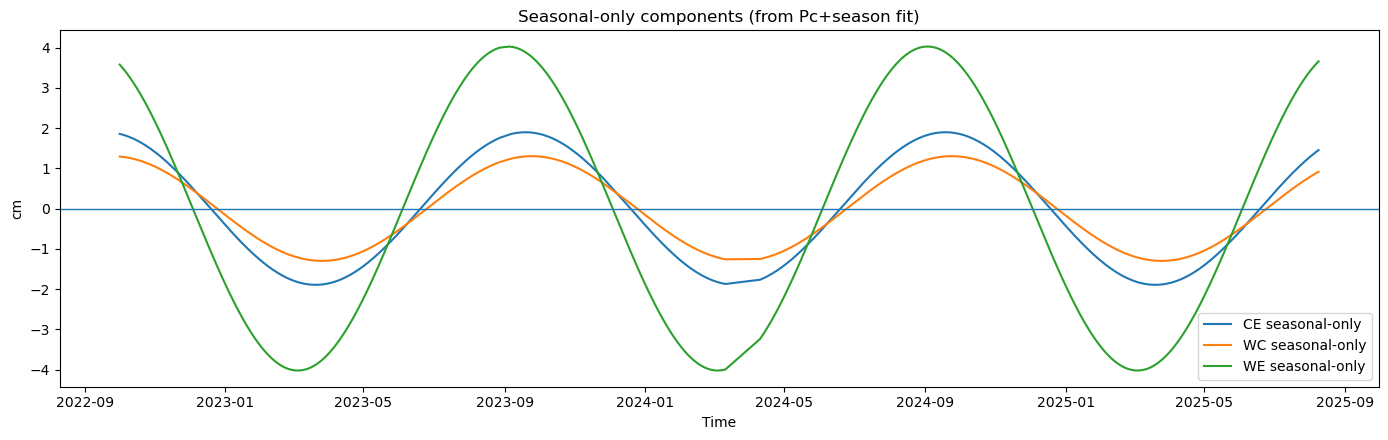

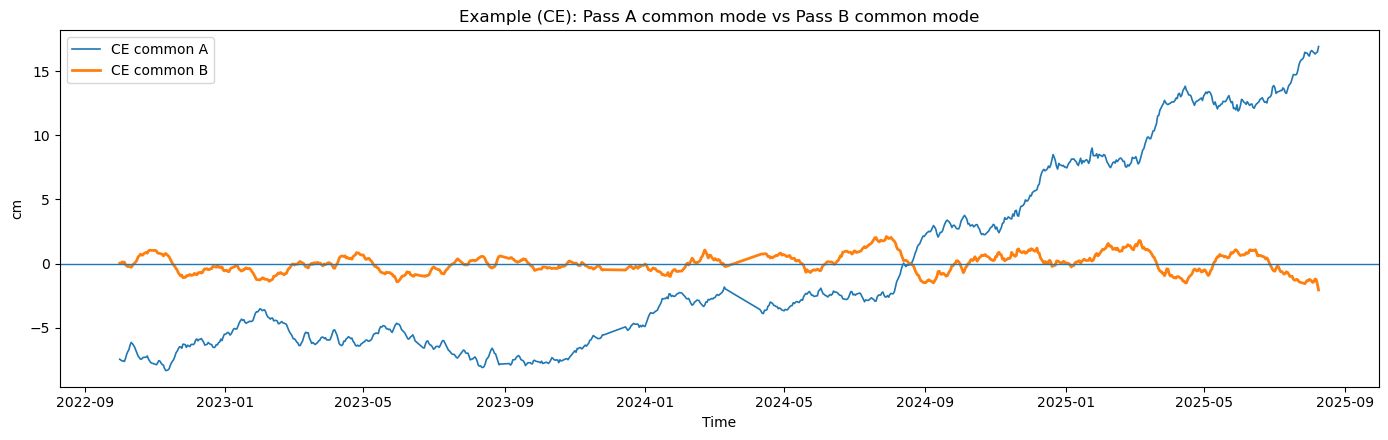

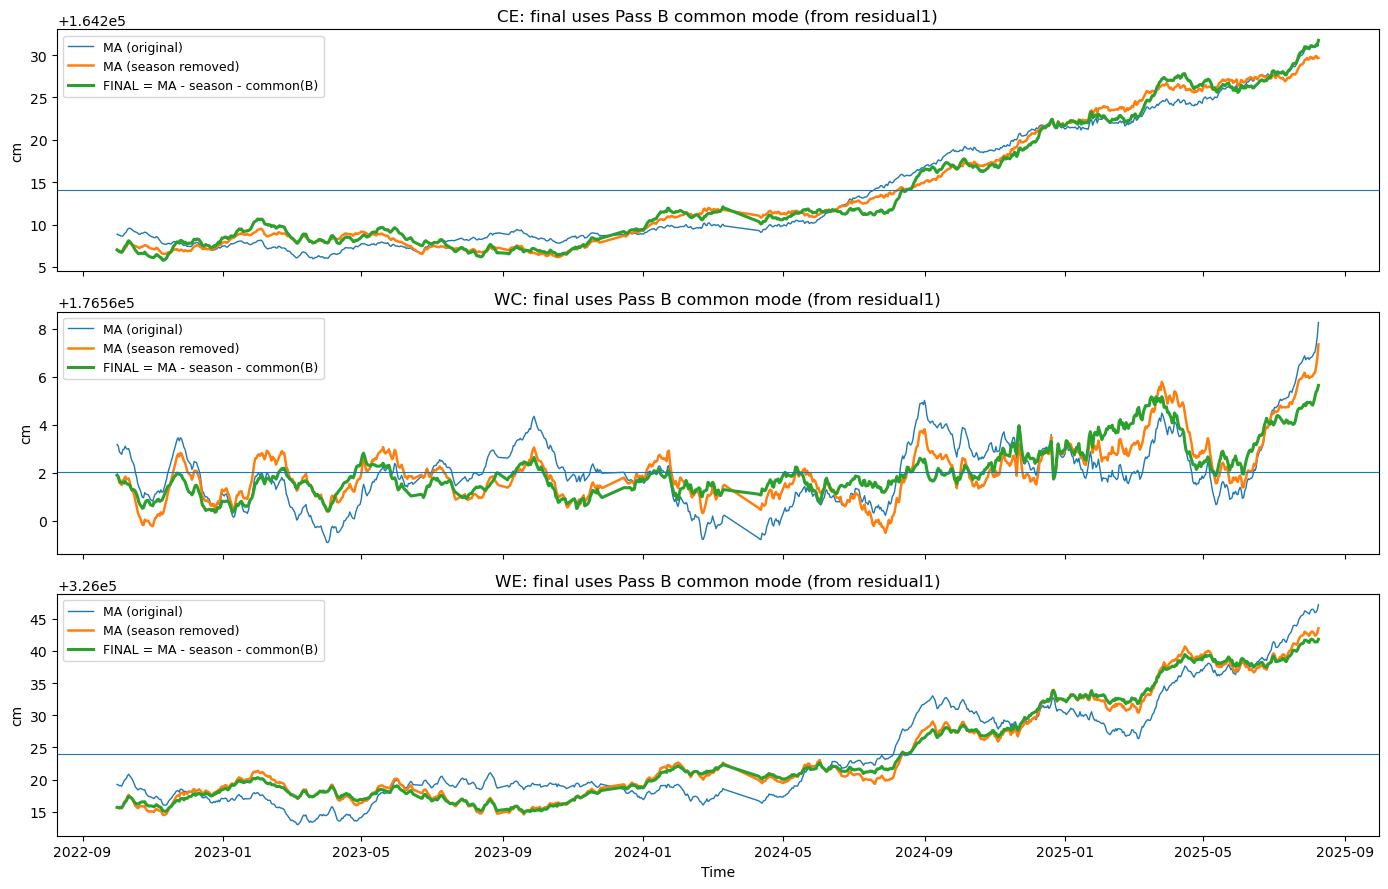

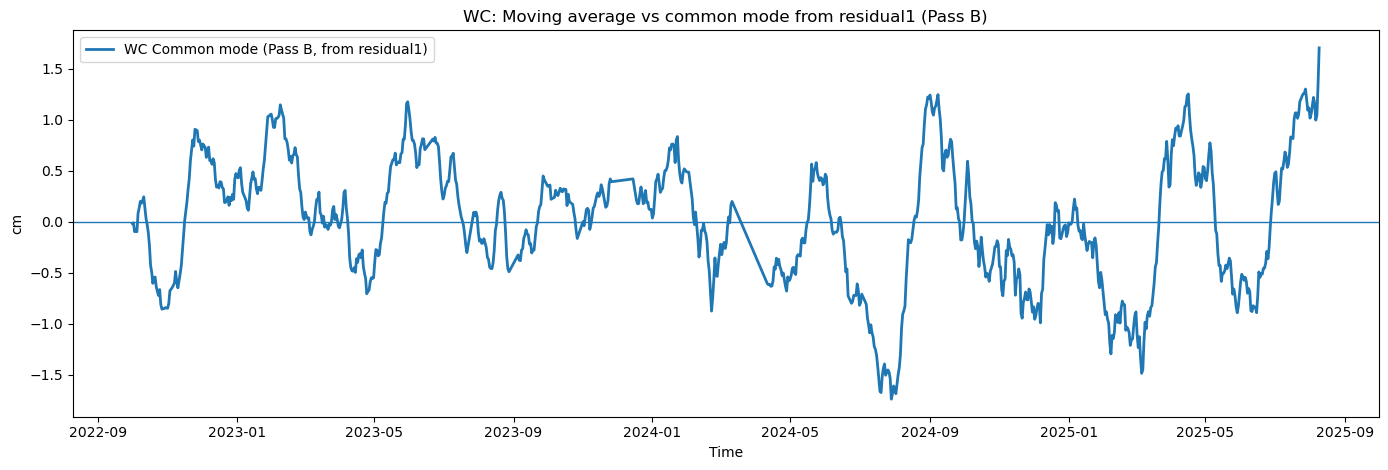

                             Pc_kPa       CE_MA_cm  CE_season_only  \
2022-10-01 00:00:00+00:00  1.347564  164208.878424        1.853800   
2022-10-02 00:00:00+00:00  1.345193  164208.764039        1.846755   
2022-10-03 00:00:00+00:00  1.341670  164208.739371        1.839164   
2022-10-04 00:00:00+00:00  1.336950  164208.689869        1.831029   
2022-10-05 00:00:00+00:00  1.331513  164208.640640        1.822351   

                           CE_season_removed       WC_MA_cm  WC_season_only  \
2022-10-01 00:00:00+00:00      164207.024624  176563.181547        1.292357   
2022-10-02 00:00:00+00:00      164206.917284  176563.121320        1.289613   
2022-10-03 00:00:00+00:00      164206.900208  176562.878855        1.286488   
2022-10-04 00:00:00+00:00      164206.858840  176562.827184        1.282982   
2022-10-05 00:00:00+00:00      164206.818289  176562.768219        1.279096   

                           WC_season_removed       WE_MA_cm  WE_season_only  \
2022-10-01 00:00:00+00:00

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOAL (two-pass common mode)
#
# Pass A:
#   1) Fit each baseline: y = a + b*Pc_z + c*sin + d*cos
#   2) Remove ONLY seasonality => y_season_removed = y - S(t)
#   3) Compute common mode CM1 from y_season_removed (SVD/PC1)
#
# Pass B:
#   4) Residual1 = y - S(t) - CM1
#   5) Compute common mode CM2 from Residual1 (SVD/PC1)
#
# Final:
#   6) y_final = y - S(t) - CM2
#      (note: CM1 is only used to define Residual1; final removes CM2)
# ============================================================

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

# -----------------------------
# Loaders
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit: y = a + b*Pc_z + c*sin + d*cos
# Return seasonal-only S(t)=c*sin + d*cos and coeffs
# -----------------------------
def fit_pc_plus_season_and_get_season(y_series, pc_series, t0_common):
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    amp = float(np.sqrt(c*c + d*d))
    return season_only, (a, b, c, d), amp

# -----------------------------
# Common mode (PC1) from a (T x 3) matrix
# returns:
#   R_common (T x 3), loadings (3,), variance explained
# -----------------------------
def common_mode_pc1(R):
    R_mean = R.mean(axis=0, keepdims=True)
    R0 = R - R_mean

    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    pc1 = U[:, 0] * S[0]
    loadings = Vt[0, :]

    R_common = np.outer(pc1, loadings)  # in each baseline's units
    var_expl = (S[0]**2) / np.sum(S**2)
    return R_common, loadings, var_expl

# ============================================================
# MAIN
# ============================================================

# 1) Load daily MA series + Pc
ce = load_baseline_daily_ma(CE_FILE, "CE")
wc = load_baseline_daily_ma(WC_FILE, "WC")
we = load_baseline_daily_ma(WE_FILE, "WE")
pc = load_pc_daily(PC_FILE)

# 2) Align to common daily window
df = pd.concat([ce, wc, we, pc], axis=1).dropna()
t = df.index
t0_common = t[0]  # consistent seasonal phase

out = pd.DataFrame(index=t)
out["Pc_kPa"] = df["Pc_kPa"]

# 3) Fit Pc+season, remove ONLY seasonality
for name in ["CE", "WC", "WE"]:
    out[f"{name}_MA_cm"] = df[name]

    season_only, (a, b, c, d), amp = fit_pc_plus_season_and_get_season(df[name], df["Pc_kPa"], t0_common)
    out[f"{name}_season_only"] = season_only
    out[f"{name}_season_removed"] = df[name].to_numpy() - season_only  # Pc not removed

    print(f"==== {name} fit y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}")
    print(f"Season amp A : {amp:.6f} cm   (peak-to-trough {2*amp:.6f} cm)\n")

# ============================================================
# PASS A: Common mode CM1 from season-removed series
# ============================================================
R_A = np.column_stack([
    out["CE_season_removed"].to_numpy(),
    out["WC_season_removed"].to_numpy(),
    out["WE_season_removed"].to_numpy()
])

R_common_A, load_A, var_A = common_mode_pc1(R_A)

print(f"PASS A: Common mode variance explained (from season-removed): {100*var_A:.1f}%")
print("PASS A loadings [CE, WC, WE]:", load_A, "\n")

out["CE_common_A"] = R_common_A[:, 0]
out["WC_common_A"] = R_common_A[:, 1]
out["WE_common_A"] = R_common_A[:, 2]

# Residual1 = y - season - CM1
for name in ["CE", "WC", "WE"]:
    out[f"{name}_residual1"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common_A"]

# ============================================================
# PASS B: Common mode CM2 from residual1
# ============================================================
R_B = np.column_stack([
    out["CE_residual1"].to_numpy(),
    out["WC_residual1"].to_numpy(),
    out["WE_residual1"].to_numpy()
])

R_common_B, load_B, var_B = common_mode_pc1(R_B)

print(f"PASS B: Common mode variance explained (from residual1): {100*var_B:.1f}%")
print("PASS B loadings [CE, WC, WE]:", load_B, "\n")

out["CE_common_B"] = R_common_B[:, 0]
out["WC_common_B"] = R_common_B[:, 1]
out["WE_common_B"] = R_common_B[:, 2]

# ============================================================
# FINAL: remove seasonality + CM2 (NOT CM1) from original length
# ============================================================
for name in ["CE", "WC", "WE"]:
    out[f"{name}_final"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common_B"]

# ============================================================
# PLOTS
# ============================================================

# Plot 1: seasonal-only terms (from Pc+season fit)
plt.figure(figsize=(14, 4.5))
for name in ["CE", "WC", "WE"]:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Seasonal-only components (from Pc+season fit)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Common modes A vs B (each in baseline units)
plt.figure(figsize=(14, 4.5))
plt.plot(out.index, out["CE_common_A"], lw=1.2, label="CE common A")
plt.plot(out.index, out["CE_common_B"], lw=2.0, label="CE common B")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Example (CE): Pass A common mode vs Pass B common mode")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Baseline comparison (original vs final)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, name in zip(axes, ["CE", "WC", "WE"]):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_season_removed"], lw=1.8, label="MA (season removed)")
    ax.plot(out.index, out[f"{name}_final"], lw=2.2, label="FINAL = MA - season - common(B)")
    ax.axhline(out[f"{name}_MA_cm"].mean(), lw=0.8)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: final uses Pass B common mode (from residual1)")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Plot 4: WC specifically — MA vs common mode from residual1 (Pass B)
plt.figure(figsize=(14, 4.8))
#plt.plot(out.index, out["WC_MA_cm"], lw=1.5, label="WC Moving Average (cm)")
plt.plot(out.index, out["WC_common_B"], lw=2.0, label="WC Common mode (Pass B, from residual1)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("WC: Moving average vs common mode from residual1 (Pass B)")
plt.legend()
plt.tight_layout()
plt.show()

print(out.head())

# OPTIONAL SAVE
# out.to_csv("two_pass_common_mode_final.csv")
# print("Saved: two_pass_common_mode_final.csv")


==== CE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 164214.178488
b (Pc_z)     : -7.335868
c (sin)      : -0.393592
d (cos)      : 1.853800
Season amp A : 1.895122 cm   (peak-to-trough 3.790245 cm)

==== WC fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 176562.090051
b (Pc_z)     : -0.826379
c (sin)      : -0.148387
d (cos)      : 1.292357
Season amp A : 1.300848 cm   (peak-to-trough 2.601696 cm)

==== WE fit y = a + b*Pc_z + c*sin + d*cos ====
a (intercept): 326024.157858
b (Pc_z)     : -7.806333
c (sin)      : -1.846276
d (cos)      : 3.575744
Season amp A : 4.024262 cm   (peak-to-trough 8.048523 cm)

PASS A: Common mode variance explained (season-removed, all baselines): 98.4%
PASS A loadings: {'CE': 0.6750156586362743, 'WC': 0.08176341190427017, 'WE': 0.7332588936178063} 

PASS B: Common mode variance explained (residual1, all baselines): 69.9%
PASS B loadings: {'CE': -0.650090345729278, 'WC': 0.5358995708566835, 'WE': 0.5386967536055978} 



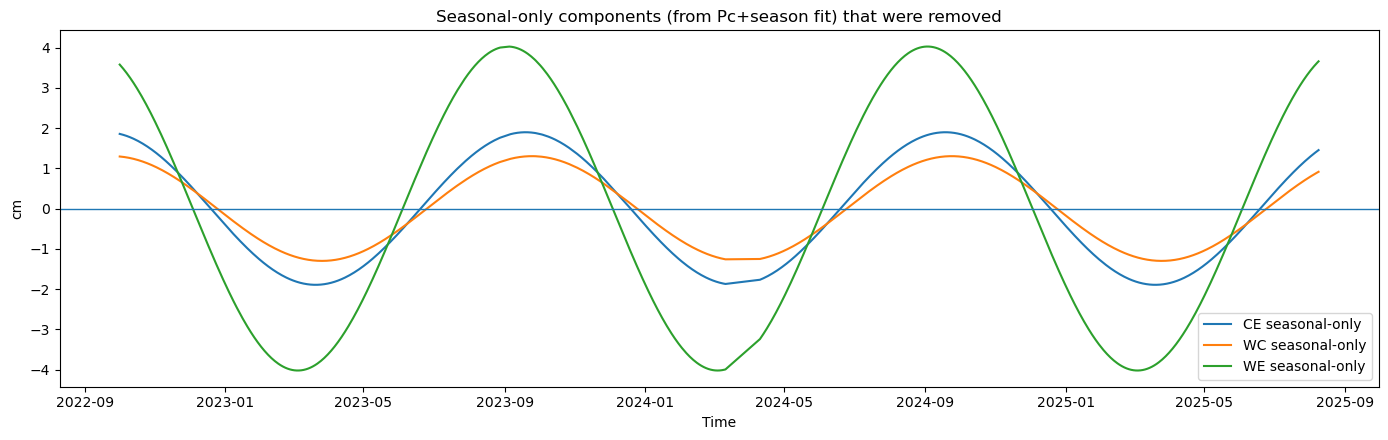

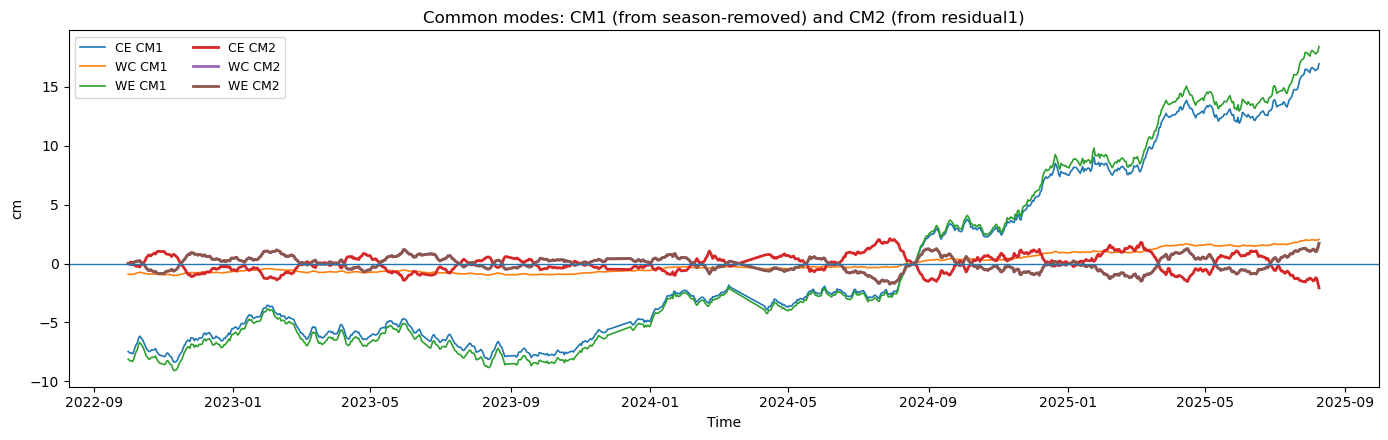

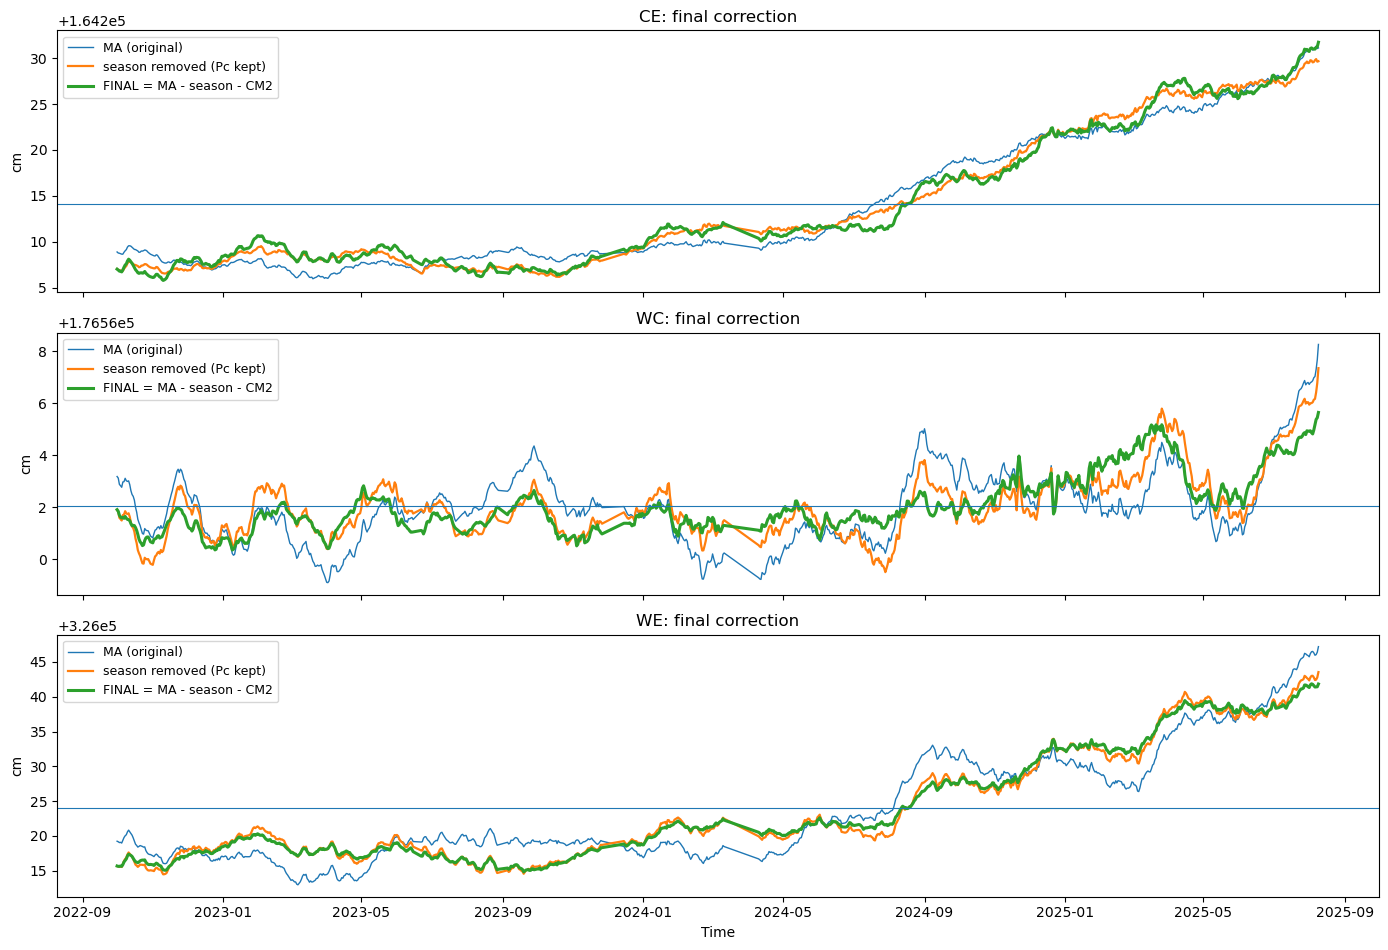

                             Pc_kPa       CE_MA_cm  CE_season_only  \
2022-10-01 00:00:00+00:00  1.347564  164208.878424        1.853800   
2022-10-02 00:00:00+00:00  1.345193  164208.764039        1.846755   
2022-10-03 00:00:00+00:00  1.341670  164208.739371        1.839164   
2022-10-04 00:00:00+00:00  1.336950  164208.689869        1.831029   
2022-10-05 00:00:00+00:00  1.331513  164208.640640        1.822351   

                           CE_season_removed       WC_MA_cm  WC_season_only  \
2022-10-01 00:00:00+00:00      164207.024624  176563.181547        1.292357   
2022-10-02 00:00:00+00:00      164206.917284  176563.121320        1.289613   
2022-10-03 00:00:00+00:00      164206.900208  176562.878855        1.286488   
2022-10-04 00:00:00+00:00      164206.858840  176562.827184        1.282982   
2022-10-05 00:00:00+00:00      164206.818289  176562.768219        1.279096   

                           WC_season_removed       WE_MA_cm  WE_season_only  \
2022-10-01 00:00:00+00:00

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOAL (All baselines, 2-pass common mode)
#
# 1) Fit each baseline: y = a + b*Pc_z + c*sin + d*cos
# 2) Remove ONLY seasonality: y_season_removed = y - S(t)   (Pc kept)
# 3) Common mode #1 (CM1) from season-removed data across ALL baselines
# 4) Residual1 = y - S(t) - CM1
# 5) Common mode #2 (CM2) from Residual1 across ALL baselines
# 6) FINAL: y_final = y - S(t) - CM2    (this is what you asked)
# ============================================================

# -----------------------------
# Files (edit as needed)
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

DROP_DAYS = 30
T_YEAR = 365.25
W = 2.0 * np.pi / T_YEAR

BASELINES = [
    ("CE", CE_FILE),
    ("WC", WC_FILE),
    ("WE", WE_FILE),
]

# -----------------------------
# Loaders
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit Pc+season, return season-only and coefficients
# -----------------------------
def fit_pc_plus_season_and_get_season(y_series, pc_series, t0_common):
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0
    sin_t = np.sin(W * t_days)
    cos_t = np.cos(W * t_days)

    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin_t, cos_t])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c, d = x

    season_only = c * sin_t + d * cos_t
    amp = float(np.sqrt(c*c + d*d))
    return season_only, (a, b, c, d), amp

# -----------------------------
# Common mode (PC1) from matrix R (T x N)
# Returns:
#   R_common: (T x N) contribution in each baseline's units
#   loadings: (N,)
#   var_expl: fraction variance explained by PC1 (after mean-centering columns)
# -----------------------------
def common_mode_pc1(R):
    R_mean = R.mean(axis=0, keepdims=True)
    R0 = R - R_mean

    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    pc1 = U[:, 0] * S[0]
    loadings = Vt[0, :]

    R_common = np.outer(pc1, loadings)
    var_expl = (S[0]**2) / np.sum(S**2)
    return R_common, loadings, var_expl

# ============================================================
# MAIN
# ============================================================

# Load baselines + Pc, align to a common daily window
series = {}
for name, path in BASELINES:
    series[name] = load_baseline_daily_ma(path, name)

pc = load_pc_daily(PC_FILE)

df = pd.concat([series[n] for n, _ in BASELINES] + [pc], axis=1).dropna()
t = df.index
t0_common = t[0]

out = pd.DataFrame(index=t)
out["Pc_kPa"] = df["Pc_kPa"]

# 1) Remove seasonality for each baseline (Pc kept)
for name, _ in BASELINES:
    out[f"{name}_MA_cm"] = df[name]

    season_only, (a, b, c, d), amp = fit_pc_plus_season_and_get_season(df[name], df["Pc_kPa"], t0_common)
    out[f"{name}_season_only"] = season_only
    out[f"{name}_season_removed"] = df[name].to_numpy() - season_only

    print(f"==== {name} fit y = a + b*Pc_z + c*sin + d*cos ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c (sin)      : {c:.6f}")
    print(f"d (cos)      : {d:.6f}")
    print(f"Season amp A : {amp:.6f} cm   (peak-to-trough {2*amp:.6f} cm)\n")

# 2) Common mode #1 from season-removed (ALL baselines)
R_A = np.column_stack([out[f"{name}_season_removed"].to_numpy() for name, _ in BASELINES])
R_common_A, load_A, var_A = common_mode_pc1(R_A)

print(f"PASS A: Common mode variance explained (season-removed, all baselines): {100*var_A:.1f}%")
print("PASS A loadings:", dict(zip([n for n, _ in BASELINES], load_A)), "\n")

for i, (name, _) in enumerate(BASELINES):
    out[f"{name}_common_A"] = R_common_A[:, i]
    out[f"{name}_residual1"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common_A"]

# 3) Common mode #2 from residual1 (ALL baselines)
R_B = np.column_stack([out[f"{name}_residual1"].to_numpy() for name, _ in BASELINES])
R_common_B, load_B, var_B = common_mode_pc1(R_B)

print(f"PASS B: Common mode variance explained (residual1, all baselines): {100*var_B:.1f}%")
print("PASS B loadings:", dict(zip([n for n, _ in BASELINES], load_B)), "\n")

for i, (name, _) in enumerate(BASELINES):
    out[f"{name}_common_B"] = R_common_B[:, i]

# 4) FINAL: remove seasonality + common mode #2 (ALL baselines)
for name, _ in BASELINES:
    out[f"{name}_final"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common_B"]

# ============================================================
# PLOTS
# ============================================================

# Plot 1: seasonal-only components removed
plt.figure(figsize=(14, 4.5))
for name, _ in BASELINES:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Seasonal-only components (from Pc+season fit) that were removed")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: common mode #1 vs #2 (in each baseline's units)
plt.figure(figsize=(14, 4.5))
for name, _ in BASELINES:
    plt.plot(out.index, out[f"{name}_common_A"], lw=1.2, label=f"{name} CM1")
for name, _ in BASELINES:
    plt.plot(out.index, out[f"{name}_common_B"], lw=2.0, label=f"{name} CM2")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Common modes: CM1 (from season-removed) and CM2 (from residual1)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Plot 3: original vs final (seasonality + CM2 removed)
fig, axes = plt.subplots(len(BASELINES), 1, figsize=(14, 3.2*len(BASELINES)), sharex=True)
if len(BASELINES) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, BASELINES):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_season_removed"], lw=1.6, label="season removed (Pc kept)")
    ax.plot(out.index, out[f"{name}_final"], lw=2.2, label="FINAL = MA - season - CM2")
    ax.axhline(out[f"{name}_MA_cm"].mean(), lw=0.8)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: final correction")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

print(out.head())

# OPTIONAL SAVE
# out.to_csv("all_baselines_two_pass_common_mode_final.csv")
# print("Saved: all_baselines_two_pass_common_mode_final.csv")


==== CE fit: y = a + b*Pc_z + (ω,2ω seasonality) ====
a (intercept): 164214.171764
b (Pc_z)     : -7.334974
c1 (sin ωt)  : -0.385262
d1 (cos ωt)  : 1.848006
c2 (sin 2ωt) : 0.104264
d2 (cos 2ωt) : -0.085534
Annual amp   : 1.887738 cm   (p2t 3.775475 cm)
Semiannual amp: 0.134860 cm  (p2t 0.269719 cm)

==== WC fit: y = a + b*Pc_z + (ω,2ω seasonality) ====
a (intercept): 176562.100761
b (Pc_z)     : -0.822282
c1 (sin ωt)  : -0.166302
d1 (cos ωt)  : 1.301573
c2 (sin 2ωt) : -0.232690
d2 (cos 2ωt) : 0.082660
Annual amp   : 1.312154 cm   (p2t 2.624309 cm)
Semiannual amp: 0.246936 cm  (p2t 0.493871 cm)

==== WE fit: y = a + b*Pc_z + (ω,2ω seasonality) ====
a (intercept): 326024.135232
b (Pc_z)     : -7.796101
c1 (sin ωt)  : -1.824318
d1 (cos ωt)  : 3.556231
c2 (sin 2ωt) : 0.263751
d2 (cos 2ωt) : -0.357954
Annual amp   : 3.996863 cm   (p2t 7.993727 cm)
Semiannual amp: 0.444630 cm  (p2t 0.889260 cm)

Common mode (PC1) variance explained (after seasonality removal): 98.4%
Loadings: {'CE': 0.675669

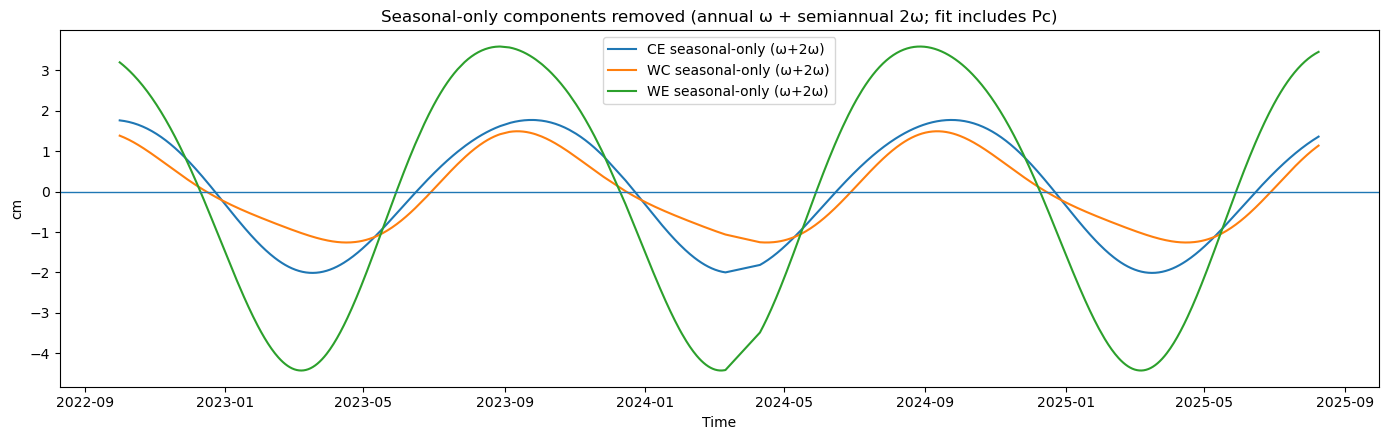

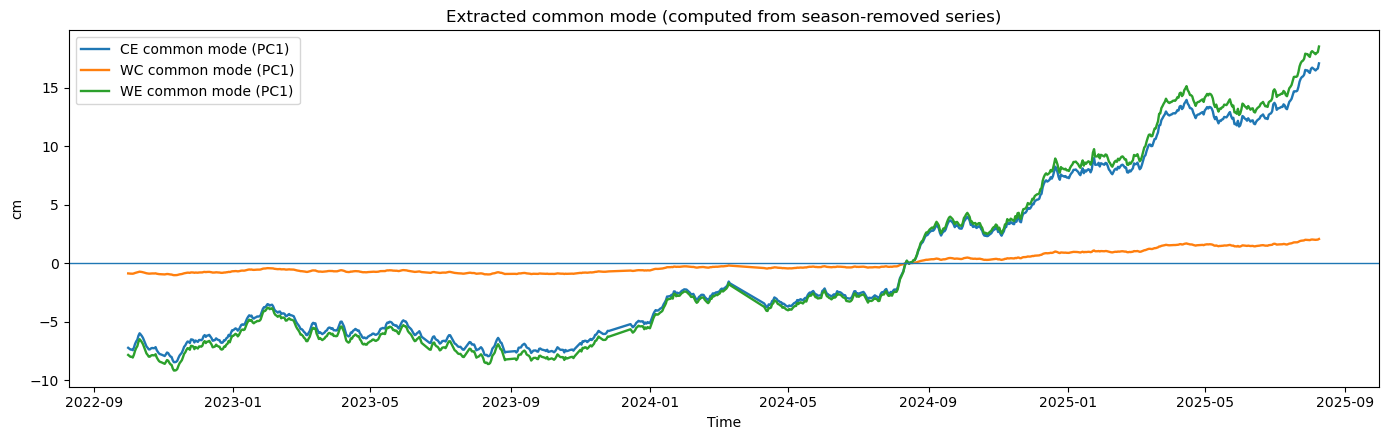

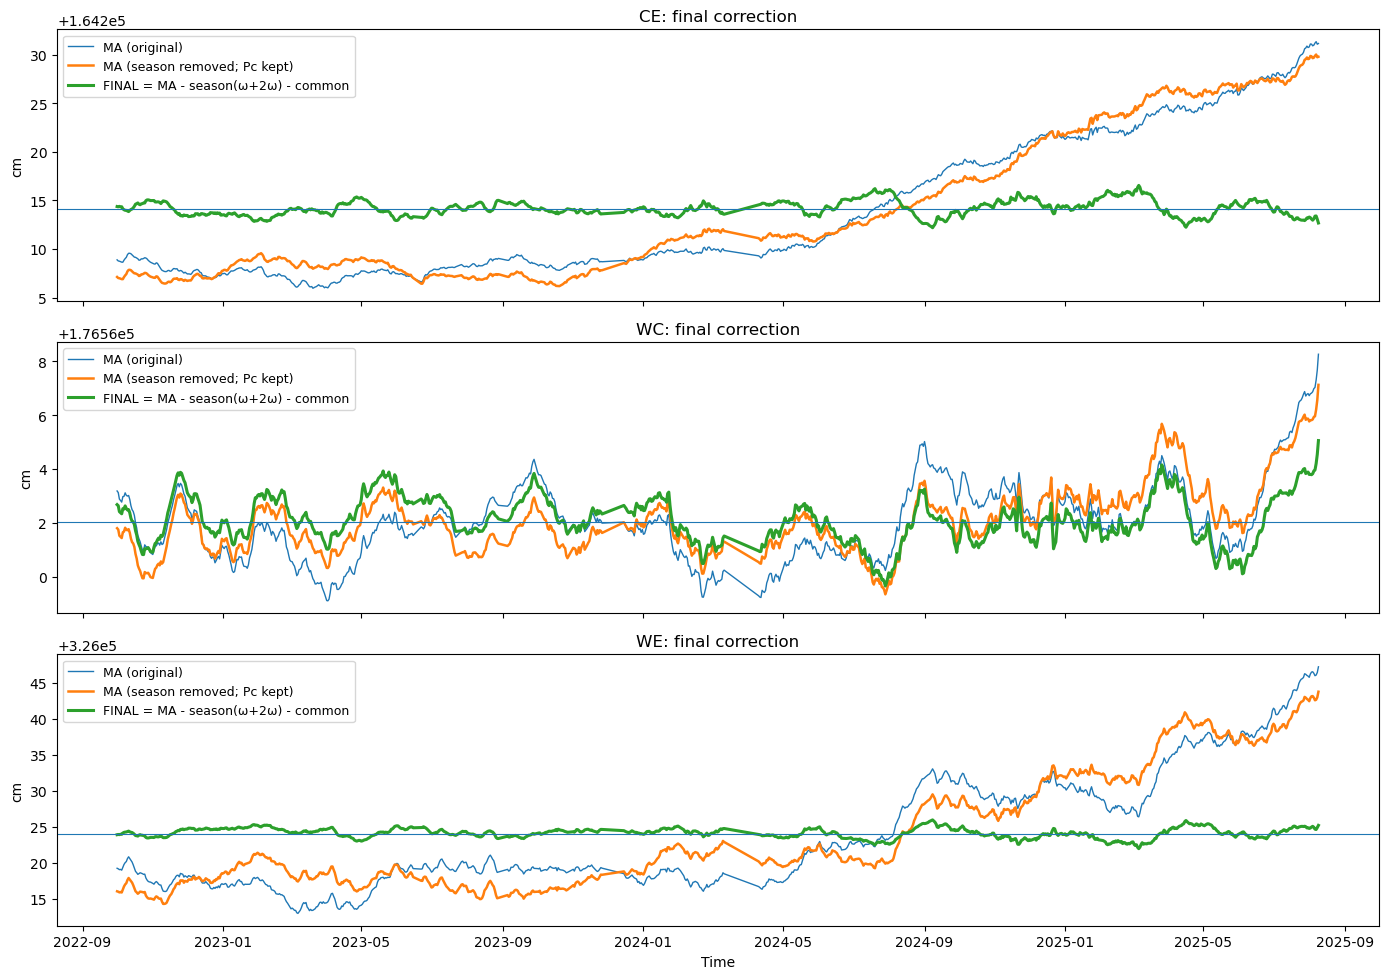

                             Pc_kPa       CE_MA_cm  CE_season_only  \
2022-10-01 00:00:00+00:00  1.347564  164208.878424        1.762472   
2022-10-02 00:00:00+00:00  1.345193  164208.764039        1.759209   
2022-10-03 00:00:00+00:00  1.341670  164208.739371        1.755498   
2022-10-04 00:00:00+00:00  1.336950  164208.689869        1.751336   
2022-10-05 00:00:00+00:00  1.331513  164208.640640        1.746722   

                           CE_season_removed       WC_MA_cm  WC_season_only  \
2022-10-01 00:00:00+00:00      164207.115952  176563.181547        1.384233   
2022-10-02 00:00:00+00:00      164207.004830  176563.121320        1.373127   
2022-10-03 00:00:00+00:00      164206.983874  176562.878855        1.361548   
2022-10-04 00:00:00+00:00      164206.938533  176562.827184        1.349507   
2022-10-05 00:00:00+00:00      164206.893917  176562.768219        1.337016   

                           WC_season_removed       WE_MA_cm  WE_season_only  \
2022-10-01 00:00:00+00:00

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOAL
#   1) Fit each baseline MA with:
#        y = a + b*Pc_z
#            + c1*sin(ωt) + d1*cos(ωt)        (annual)
#            + c2*sin(2ωt) + d2*cos(2ωt)      (2nd harmonic / semiannual)
#   2) Define seasonality S(t) as the sum of the sin/cos terms above
#   3) Remove seasonality: y_season_removed = y - S(t)   (Pc kept)
#   4) Find a common mode (PC1) from y_season_removed across all baselines
#   5) FINAL: y_final = y - S(t) - common_mode
# ============================================================

# -----------------------------
# Files
# -----------------------------
CE_FILE = "CE_distance_corrected.csv"
WC_FILE = "WC_distance_corrected.csv"
WE_FILE = "WE_distance_corrected.csv"
PC_FILE = "Pc_drifcor.csv"

BASELINES = [("CE", CE_FILE), ("WC", WC_FILE), ("WE", WE_FILE)]

DROP_DAYS = 30
T_YEAR = 365.25
OMEGA = 2.0 * np.pi / T_YEAR  # ω in rad/day (since t is in days)

# -----------------------------
# Loaders
# -----------------------------
def load_baseline_daily_ma(path, name):
    df = pd.read_csv(path)
    df["Record Time"] = pd.to_datetime(df["Record Time"], utc=True, errors="coerce")
    df = df.dropna(subset=["Record Time"]).sort_values("Record Time")

    t0 = df["Record Time"].iloc[0]
    df = df[df["Record Time"] >= (t0 + pd.Timedelta(days=DROP_DAYS))].copy()

    s = df.set_index("Record Time")["Moving Average (cm)"].resample("1D").mean()
    s.name = name
    return s

def load_pc_daily(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time")
    s = df.set_index("time")["pressure_kPa"].resample("1D").mean()
    s.name = "Pc_kPa"
    return s

# -----------------------------
# Fit: y = a + b*Pc_z + seasonal(ω,2ω)
# Return:
#   season_only = c1*sin(ωt)+d1*cos(ωt)+c2*sin(2ωt)+d2*cos(2ωt)
# -----------------------------
def fit_pc_plus_season_omega(y_series, pc_series, t0_common):
    Pc = pc_series.to_numpy()
    Pc_z = (Pc - Pc.mean()) / Pc.std()

    t_days = (y_series.index - t0_common).total_seconds() / 86400.0

    sin1 = np.sin(OMEGA * t_days)
    cos1 = np.cos(OMEGA * t_days)
    sin2 = np.sin(2.0 * OMEGA * t_days)
    cos2 = np.cos(2.0 * OMEGA * t_days)

    # columns: [1, Pc_z, sin(ωt), cos(ωt), sin(2ωt), cos(2ωt)]
    A = np.column_stack([np.ones_like(Pc_z), Pc_z, sin1, cos1, sin2, cos2])
    y = y_series.to_numpy()

    x, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, c1, d1, c2, d2 = x

    season_only = c1 * sin1 + d1 * cos1 + c2 * sin2 + d2 * cos2

    amp1 = float(np.sqrt(c1*c1 + d1*d1))  # annual amplitude
    amp2 = float(np.sqrt(c2*c2 + d2*d2))  # semiannual amplitude
    return season_only, (a, b, c1, d1, c2, d2), (amp1, amp2)

# -----------------------------
# Common mode (PC1) across N baselines
# Input R: (T x N)
# Output R_common: (T x N) in each baseline's units
# -----------------------------
def common_mode_pc1(R):
    R_mean = R.mean(axis=0, keepdims=True)
    R0 = R - R_mean

    U, S, Vt = np.linalg.svd(R0, full_matrices=False)
    pc1 = U[:, 0] * S[0]
    loadings = Vt[0, :]

    R_common = np.outer(pc1, loadings)
    var_expl = (S[0]**2) / np.sum(S**2)
    return R_common, loadings, var_expl

# ============================================================
# MAIN
# ============================================================

# Load and align
series = {name: load_baseline_daily_ma(path, name) for name, path in BASELINES}
pc = load_pc_daily(PC_FILE)

df = pd.concat([series[name] for name, _ in BASELINES] + [pc], axis=1).dropna()
t = df.index
t0_common = t[0]

out = pd.DataFrame(index=t)
out["Pc_kPa"] = df["Pc_kPa"]

# 1) Fit and remove seasonality (Pc kept)
for name, _ in BASELINES:
    out[f"{name}_MA_cm"] = df[name]

    season_only, coeffs, (amp1, amp2) = fit_pc_plus_season_omega(df[name], df["Pc_kPa"], t0_common)
    out[f"{name}_season_only"] = season_only
    out[f"{name}_season_removed"] = df[name].to_numpy() - season_only

    a, b, c1, d1, c2, d2 = coeffs
    print(f"==== {name} fit: y = a + b*Pc_z + (ω,2ω seasonality) ====")
    print(f"a (intercept): {a:.6f}")
    print(f"b (Pc_z)     : {b:.6f}")
    print(f"c1 (sin ωt)  : {c1:.6f}")
    print(f"d1 (cos ωt)  : {d1:.6f}")
    print(f"c2 (sin 2ωt) : {c2:.6f}")
    print(f"d2 (cos 2ωt) : {d2:.6f}")
    print(f"Annual amp   : {amp1:.6f} cm   (p2t {2*amp1:.6f} cm)")
    print(f"Semiannual amp: {amp2:.6f} cm  (p2t {2*amp2:.6f} cm)\n")

# 2) Common mode from season-removed data across all baselines
R = np.column_stack([out[f"{name}_season_removed"].to_numpy() for name, _ in BASELINES])
R_common, loadings, var_expl = common_mode_pc1(R)

print(f"Common mode (PC1) variance explained (after seasonality removal): {100*var_expl:.1f}%")
print("Loadings:", dict(zip([n for n, _ in BASELINES], loadings)), "\n")

for i, (name, _) in enumerate(BASELINES):
    out[f"{name}_common"] = R_common[:, i]

# 3) FINAL: subtract seasonality + common mode from original
for name, _ in BASELINES:
    out[f"{name}_final"] = out[f"{name}_MA_cm"] - out[f"{name}_season_only"] - out[f"{name}_common"]

# ============================================================
# PLOTS
# ============================================================

# Plot 1: seasonal-only terms removed (ω + 2ω)
plt.figure(figsize=(14, 4.5))
for name, _ in BASELINES:
    plt.plot(out.index, out[f"{name}_season_only"], lw=1.5, label=f"{name} seasonal-only (ω+2ω)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Seasonal-only components removed (annual ω + semiannual 2ω; fit includes Pc)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: common mode contributions in each baseline
plt.figure(figsize=(14, 4.5))
for name, _ in BASELINES:
    plt.plot(out.index, out[f"{name}_common"], lw=1.7, label=f"{name} common mode (PC1)")
plt.axhline(0, lw=1)
plt.xlabel("Time")
plt.ylabel("cm")
plt.title("Extracted common mode (computed from season-removed series)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: original vs final
fig, axes = plt.subplots(len(BASELINES), 1, figsize=(14, 3.3*len(BASELINES)), sharex=True)
if len(BASELINES) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, BASELINES):
    ax.plot(out.index, out[f"{name}_MA_cm"], lw=1.0, label="MA (original)")
    ax.plot(out.index, out[f"{name}_season_removed"], lw=1.8, label="MA (season removed; Pc kept)")
    ax.plot(out.index, out[f"{name}_final"], lw=2.2, label="FINAL = MA - season(ω+2ω) - common")
    ax.axhline(out[f"{name}_MA_cm"].mean(), lw=0.8)
    ax.set_ylabel("cm")
    ax.set_title(f"{name}: final correction")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

print(out.head())

# OPTIONAL SAVE
# out.to_csv("season_omega2omega_common_removed.csv")
# print("Saved: season_omega2omega_common_removed.csv")
